In [3]:
'''
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
'''

'\n# This Python 3 environment comes with many helpful analytics libraries installed\n# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python\n# For example, here\'s several helpful packages to load\n\nimport numpy as np # linear algebra\nimport pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)\n\n# Input data files are available in the read-only "../input/" directory\n# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory\n\nimport os\nfor dirname, _, filenames in os.walk(\'/kaggle/input\'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n\n# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" \n# You can also write temporary files to /kaggle/temp/, but they won\'t be saved outside of the current session\n'

## Import The Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 572.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.0/869.0 kB 5.4 MB/s eta 0:00:00a 0:00:01


In [24]:
import glob
from PIL import Image
import ultralytics
from ultralytics import YOLO
from IPython.display import display
from glob import glob
import cv2
import random
import os

## Read The Data

In [25]:
class Sys:
    EPOCHS=50
    BATCH_SIZE=32
    SEED = 6
    LEARNING_RATE = 0.001
    NUM_SAMPLES = 16
    OPTIMIZER = 'Adam'
    ds='dataset/data.yaml'
    samples='train/images/*'

In [26]:
images_for_vis = glob(Sys.samples)
random_image = random.sample(images_for_vis, Sys.NUM_SAMPLES)

plt.figure(figsize=(12,10))
for i in range(Sys.NUM_SAMPLES):
    plt.subplot(4,4,i+1)
    plt.imshow(cv2.imread(random_image[i]))
    plt.axis('on')

<Figure size 1200x1000 with 0 Axes>

## Build & Train The Model

In [27]:
yolo_v8 = YOLO('yolov8m.pt')

In [29]:
v8_model = yolo_v8.train(data=Sys.ds,seed=Sys.SEED,epochs=Sys.EPOCHS, lr0=Sys.LEARNING_RATE, optimizer=Sys.OPTIMIZER, verbose=True,project='ft_models',name='yolo_v8')

Ultralytics 8.3.55 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=ft_models, name=yolo_v86, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=6, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

RuntimeError: Dataset 'dataset/data.yaml' error ❌ 
Dataset 'dataset/data.yaml' images not found ⚠️, missing path '/home/huzbntu/Stuff/cui/F/Eisha/fyp/datasets/dataset/valid/images'
Note dataset download directory is '/home/huzbntu/Stuff/cui/F/Eisha/fyp/datasets'. You can update this in '/home/huzbntu/.config/Ultralytics/settings.json'

In [11]:
def stone_detection(img_path, model):
    img = cv2.imread(img_path)
    detect_result = model(img)
    detect_img = detect_result[0].plot()
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
    return detect_img

## Testing

In [12]:
df = '/kaggle/input/kidney-stone-images/test/images'

In [13]:
df_testing = os.listdir(df)

In [14]:
selected_images = random.sample(df_testing, 16)

In [15]:
model_trained = YOLO('/kaggle/working/ft_models/yolo_v8/weights/best.pt')


0: 544x640 1 Tas_Var, 88.6ms
Speed: 2.0ms preprocess, 88.6ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Tas_Vars, 34.8ms
Speed: 2.0ms preprocess, 34.8ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Tas_Vars, 29.9ms
Speed: 2.5ms preprocess, 29.9ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 4 Tas_Vars, 29.5ms
Speed: 2.3ms preprocess, 29.5ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Tas_Var, 29.5ms
Speed: 1.8ms preprocess, 29.5ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Tas_Var, 29.7ms
Speed: 2.4ms preprocess, 29.7ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Tas_Var, 27.6ms
Speed: 1.8ms preprocess, 27.6ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Tas_Vars, 18.7ms
Speed: 2.4ms preprocess, 18.7ms inference, 1.2ms postprocess per image at sha

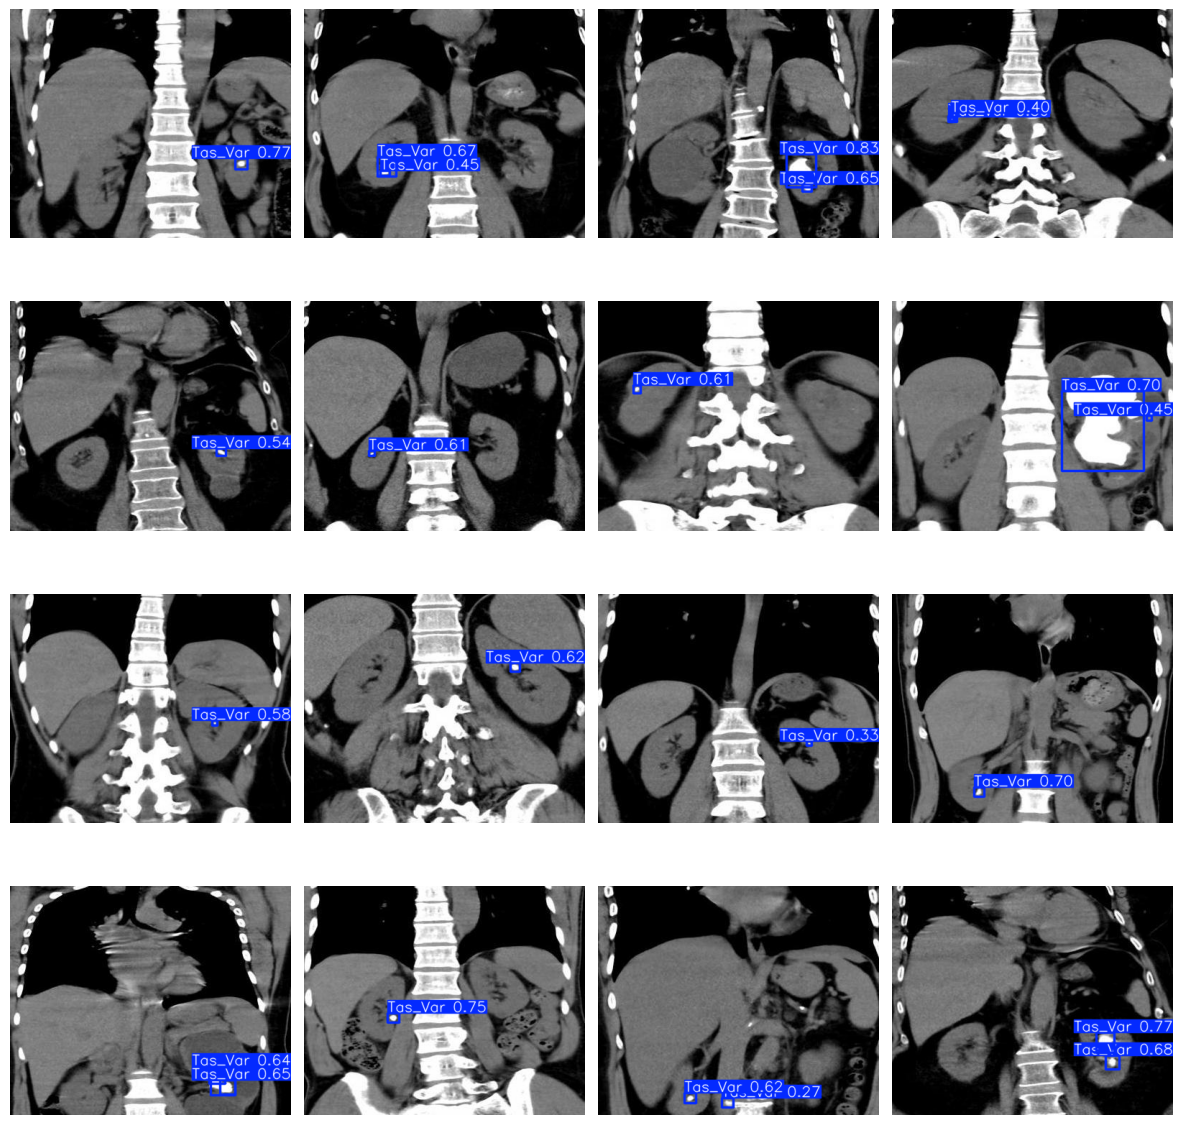

In [16]:
# Create a figure with subplots for each image
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))

for i, img_file in enumerate(selected_images):
    
    # Compute the row and column index of the current subplot
    row_idx = i // 4
    col_idx = i % 4
    
    # Load the current image and run object detection
    img_path = os.path.join(df, img_file)
    detect_img = stone_detection(img_path, model_trained)
    
    # Plot the current image on the appropriate subplot
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis('off')

# Adjust the spacing between the subplots
plt.subplots_adjust(wspace=0.05, hspace=0.05)

In [17]:
results = pd.read_csv('/kaggle/working/ft_models/yolo_v8/results.csv')
results

,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,2.2631,2.81260,1.3580,0.55890,0.41231,0.42928,0.16059,2.1041,2.07860,1.2216,0.067500,0.000328,0.000328
1,2,2.1081,1.24510,1.2921,0.48632,0.56615,0.39508,0.15108,1.9826,1.97890,1.2133,0.034487,0.000649,0.000649
2,3,2.1675,1.22780,1.3220,0.68408,0.59298,0.59633,0.21149,2.0760,1.38940,1.2497,0.001461,0.000956,0.000956
3,4,2.1219,1.23180,1.3111,0.60853,0.58154,0.56104,0.21027,2.0289,1.18630,1.1964,0.000941,0.000941,0.000941
4,5,2.0891,1.12560,1.2703,0.68560,0.60615,0.61938,0.24077,2.0265,1.08580,1.1993,0.000921,0.000921,0.000921
5,6,2.0727,1.12260,1.2782,0.75035,0.64000,0.64800,0.23110,2.1073,1.26150,1.2411,0.000901,0.000901,0.000901
6,7,2.0560,1.09560,1.2375,0.73947,0.66769,0.67721,0.27183,2.0087,1.01570,1.1872,0.000881,0.000881,0.000881
7,8,2.0723,1.10820,1.2653,0.69870,0.66154,0.62048,0.23347,2.0880,1.25100,1.2220,0.000861,0.000861,0.000861
8,9,1.9917,1.08410,1.2169,0.75212,0.62462,0.67037,0.27596,2.0220,1.13450,1.1857,0.000842,0.000842,0.000842
9,10,2.0230,1.06780,1.2287,0.66548,0.63692,0.67075,0.26112,1.9944,1.15060,1.1424,0.000822,0.000822,0.000822


In [18]:
results.columns

Index(['                  epoch', '         train/box_loss',
       '         train/cls_loss', '         train/dfl_loss',
       '   metrics/precision(B)', '      metrics/recall(B)',
       '       metrics/mAP50(B)', '    metrics/mAP50-95(B)',
       '           val/box_loss', '           val/cls_loss',
       '           val/dfl_loss', '                 lr/pg0',
       '                 lr/pg1', '                 lr/pg2'],
      dtype='object')

(-0.5, 2249.5, 1499.5, -0.5)

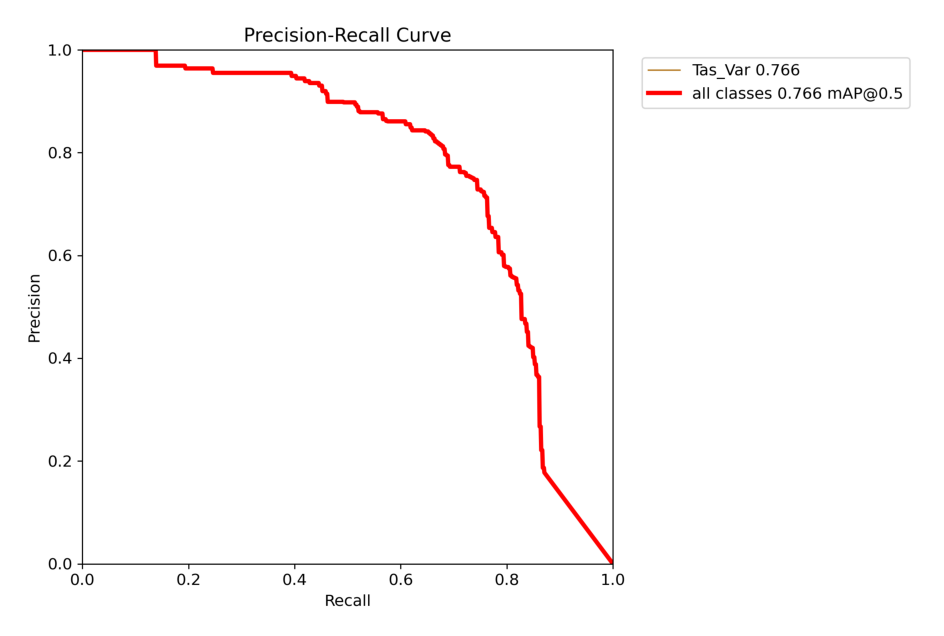

In [19]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.imread('/kaggle/working/ft_models/yolo_v8/PR_curve.png'))
plt.axis('off')

In [24]:
single_image='/kaggle/input/kidney-stone-images/valid/images/1-3-46-670589-33-1-63737661477473189500001-5463064330587912766_png_jpg.rf.72d5fd49b7ea305b3167bb1d7ac8dbc7.jpg'

In [25]:
y = model_trained.predict(single_image)

print(type(y))


image 1/1 /kaggle/input/kidney-stone-images/valid/images/1-3-46-670589-33-1-63737661477473189500001-5463064330587912766_png_jpg.rf.72d5fd49b7ea305b3167bb1d7ac8dbc7.jpg: 544x640 1 Tas_Var, 34.9ms
Speed: 2.3ms preprocess, 34.9ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)
<class 'list'>


In [26]:

def show_single_image(img_file, df, model_trained, stone_detection):
    # Load the current image and run object detection
    img_path = os.path.join(df, img_file)
    detect_img = stone_detection(img_path, model_trained)
    
    # Create a figure and axis for a single image
    fig, ax = plt.subplots(figsize=(5,5))
    
    # Plot the current image
    ax.imshow(detect_img)
    ax.axis('off')  
    
    plt.show()


0: 544x640 1 Tas_Var, 34.9ms
Speed: 2.9ms preprocess, 34.9ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)


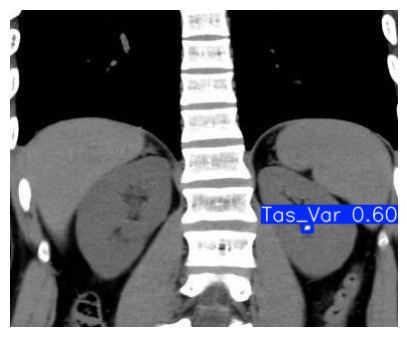

In [27]:
show_single_image(single_image,df,model_trained,stone_detection)